#### Impact of Hypothesis 1 violations on the completeness of Algorithm 2 (Corollary 2)

For each run we compute the oracle $\theta_{\mathcal{G}}=\min\{\theta\in\mathcal{G}:B_{\delta/J}(\theta)\le r^*\}$
and the threshold returned by Algorithm 2, and call the run complete when the two coincide. Runs
where $\Theta=\emptyset$ are not counted, Corollary 2 assuming $\Theta\neq\emptyset$. Both sides read
off the same bound path, so unlike the validity of the guarantee this is directly testable.

In [6]:
%run -i ../python_scripts/nb_setup.py
from joblib import cpu_count

In [7]:
METRICS = ["standard", "FPR", "FNR"]
THETA_MIN, THETA_MAX = 0, 1
RANKINGS = [
    0,
    0.01,
    0.02,
    0.05,
    0.07,
    0.1,
    0.3,
    0.5,
    0.7,
    0.9,
    1.1,
    1.5,
    2,
    3,
    6,
    np.inf,
]
SIZES = np.arange(2000, 51000, 2000)
NUM_SEEDS = 500
R_STARS = [0.05, 0.1, 0.15, 0.2]
N_CPUS = int(4 * cpu_count() / 5)

In [8]:
tasks = [(n, r, s) for n in SIZES for r in RANKINGS for s in range(NUM_SEEDS)]
chunks = Parallel(n_jobs=N_CPUS)(
    delayed(run_one)(n, r, s, METRICS, R_STARS, THETA_MIN, THETA_MAX, DELTA)
    for n, r, s in tasks
)

res = pd.DataFrame([rec for c in chunks for rec in c])
res["discordant"] = 100 * (1 - res.auc_emp)
# NaN on the uncounted runs, so groupby means are taken among non-empty Theta
res["complete"] = np.where(res.status.eq("empty"), np.nan, res.status.eq("exact"))

In [ ]:
res = pickle.load(open("completeness_res", "rb"))

In [9]:
cols = ["discordant", "complete"]
display(res.groupby(["metric", "r_star", "ranking"])[cols].mean().round(4))

discordant  complete
metric   r_star ranking                      
FNR      0.05   0.5         27.6040    0.9995
                0.7         21.3017    0.9932
                0.9         16.4866    0.9991
                1.1         12.9159    0.9999
                1.5          8.2745    0.9986
...                             ...       ...
standard 0.20   1.5          8.2792    0.9999
                2.0          5.1651    1.0000
                3.0          2.4880    1.0000
                6.0          0.6536    1.0000
                inf          0.0000    1.0000

[141 rows x 2 columns]

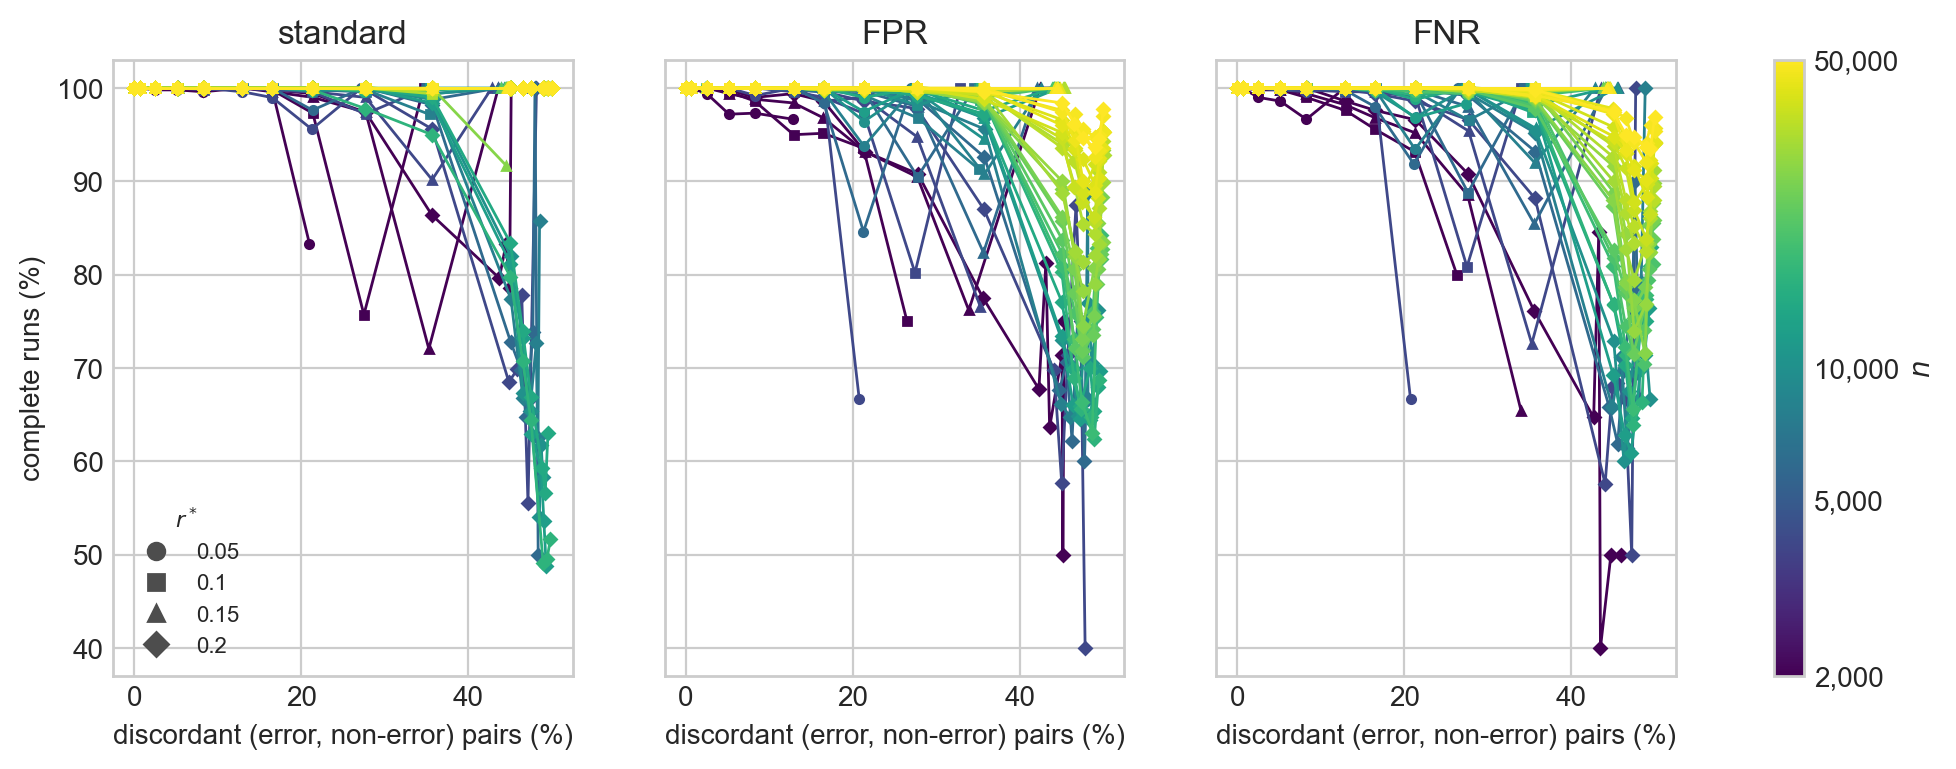

In [10]:
MARKERS = dict(zip(R_STARS, ["o", "s", "^", "D", "v", "P"]))

ns = sorted(res.n.unique())
cnorm, cmap = LogNorm(vmin=min(ns), vmax=max(ns)), plt.cm.viridis

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(
        1, len(METRICS), figsize=(4.2 * len(METRICS), 4), dpi=200, sharey=True
    )
    for ax, metric in zip(np.atleast_1d(axes), METRICS):
        for (n, r_star), g in res[res.metric == metric].groupby(["n", "r_star"]):
            m = g.groupby("ranking")[["discordant", "complete"]].mean().dropna()
            m = m.sort_values("discordant")
            ax.plot(
                m.discordant,
                100 * m.complete,
                marker=MARKERS[r_star],
                ms=3,
                lw=1.0,
                color=cmap(cnorm(n)),
            )
        ax.set_xlabel("discordant (error, non-error) pairs (%)")
        ax.set_title(metric)
    np.atleast_1d(axes)[0].set_ylabel("complete runs (%)")
    np.atleast_1d(axes)[0].legend(
        handles=[
            Line2D([], [], marker=MARKERS[r], ls="none", color="0.3", label=f"{r}")
            for r in R_STARS
        ],
        title="$r^*$",
        fontsize=8,
        title_fontsize=8,
    )
    ticks = sorted(
        {min(ns), 1000, 2000, 5000, 10000, max(ns)} & set(range(min(ns), max(ns) + 1))
    )
    cbar = fig.colorbar(ScalarMappable(norm=cnorm, cmap=cmap), ax=axes, ticks=ticks)
    cbar.ax.minorticks_off()
    cbar.ax.set_yticklabels([f"{t:,}" for t in ticks])
    cbar.set_label("$n$")
    plt.show()

# + PLOT MEAN ACROSS ALL R AND ALL N